In [1]:
import numpy as np 
import pickle 
import h5py
from scipy import stats
from tqdm.auto import tqdm, trange
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr
import pandas as pd
from pathlib import Path

%matplotlib inline 
import matplotlib.pyplot as plt
import seaborn as sns
import src.util_analysis as util_analysis

In [ ]:
h5_dir = Path("binaural_unit_activation_analysis")
model = "word_task_v10_main_feature_gain_config"
h5_path = h5_dir / f"{model}/{model}_model_activations_0dB_diotic.h5"

In [3]:
acts =  h5py.File(h5_path, 'r')
all_act_keys = list(acts.keys())
target_locs = acts['target_loc'][:]
acts.close()
# [key.split("_mixture")[0] for key in all_act_keys if ("mixture" in key) and (not any([str_part in key for str_part in ['f0', 'loc', 'word']]))]


In [4]:
h5_file = h5py.File(h5_path, 'r') 
layer_names = sorted(list(set([l.split('_target')[0] for l in all_act_keys if 'target' in l and not  any([str_part in l for str_part in ['_f0', '_loc', '_word']])]))) # set to remove duplicates 
for layer in range(7):
    tgt_unit_acts = h5_file[f'hann_pool_{layer}_target'][:].sum(0)
    tgt_dead_units = np.where(tgt_unit_acts == 0)[0]
    # print(len(tgt_dead_units)) 
    dist_unit_acts = h5_file[f'hann_pool_{layer}_same_sex_dist'][:].sum(0)
    dist_dead_units = np.where(tgt_unit_acts == 0)[0]
    # print(len(dist_dead_units)) 
    print(f"layer {layer} all same: {all(dist_dead_units == tgt_dead_units)}")
h5_file.close()

layer 0 all same: True
layer 1 all same: True
layer 2 all same: True
layer 3 all same: True
layer 4 all same: True
layer 5 all same: True
layer 6 all same: True


In [39]:
import scipy
vec_pearsonr = np.vectorize(scipy.stats.pearsonr,
                signature='(n),(n)->(),()')

# for path in paths:
distractor_conditions = ['same_sex_talker', 'diff_sex_talker', 'natural_scene']

# just look at 0,0 co-located examples 
# wanted_rows = np.where(np.all(target_locs == [0,0], axis=1))[0]

dfs = []
with h5py.File(h5_path, 'r') as acts:
    ## Get keys with corr in them 
    layer_names = set([l.split('_target')[0] for l in all_act_keys if any([n in l for n in ['relu', 'cochleagram']]) and 'target' in l and not  any([str_part in l for str_part in ['_f0', '_loc', '_word']])]) # set to remove duplicates 
    print(layer_names)
    # break 
    # records = []
    for layer in tqdm(layer_names):
        ## Get good unit ixs first 
        unit_acts = acts[f"{layer}_target"][:].sum(0)
        good_units = np.where(unit_acts > 0)[0]
        fg_key = f"{layer}_target"
        N_examples = acts[fg_key].shape[0]
        bg_key = f"{layer}_diff_sex_dist"
        # if layer == 'cochleagram':
            # bg_key = bg_key.replace('sex_', '')   
        mix_key = f"{layer}_mixture_diff"

        fg_acts = acts[fg_key][:][:, good_units]
        bg_acts = acts[bg_key][:][:, good_units]
        mix_acts = acts[mix_key][:][:, good_units]

        fg_corrs_full = acts[f"{layer}_target_mixture_diff_corr"][:, 0]
        if layer == "cochleagram":
            bg_corrs_full = acts[f"{layer}_diff_dist_mixture_diff_corr"][:, 0]
        else:
            bg_corrs_full = acts[f"{layer}_diff_sex_dist_mixture_diff_corr"][:, 0]

        # get fg mix correlations 
        fg_corr, _ = vec_pearsonr(fg_acts, mix_acts)
        bg_corr, _ = vec_pearsonr(bg_acts, mix_acts)
        
        data_dict = {}
        data_dict['fg_corrs_filt_du'] = fg_corr
        data_dict['bg_corrs_filt_du'] = bg_corr
        data_dict['fg_corrs_full'] = fg_corrs_full
        data_dict['bg_corrs_full'] = bg_corrs_full

        data_dict['layer'] = [layer] * N_examples
        data_dict['distractor_condition'] = ["diff_sex_talker"] * N_examples

        df = pd.DataFrame(data_dict)
        df['model_name'] = util_analysis.model_name_dict[h5_path.parent.name]
        dfs.append(df)

        # for eg in trange(N_examples, leave=False):
        #     # for dist_cond in tqdm(distractor_conditions, leave=False):
        #     # if dist_cond == 'same_sex_talker':
        #     # elif dist_cond == 'diff_sex_talker':
        #     #     bg_key = f"{layer}_diff_sex_dist"
        #     # elif dist_cond == 'natural_scene':
        #     #     bg_key = f"{layer}_nat_scene_dist"   
        #     # if layer == 'cochleagram':
        #     #     bg_key = bg_key.replace('sex_', '')      

        #     data_dict = {}
        #     fg_corr = pearsonr(fg_acts[eg], mix_acts[eg])[0]
        #     bg_corr = pearsonr(bg_acts[eg], mix_acts[eg])[0]
        #     data_dict['fg_corrs'] = fg_corr
        #     data_dict['bg_corrs'] = bg_corr
        #     data_dict['layer'] = layer
        #     data_dict['distractor_condition'] = "same_sex_talker"
        #     data_dict['model_name'] = util_analysis.model_name_dict[h5_path.parent.name]
        #     records.append(data_dict)


            # 
act_results  = pd.concat(dfs, ignore_index=True)

# act_results = pd.DataFrame.from_records(records)
act_results['layer'] = act_results['layer'].str.replace('_block_', '')

# act_results['log_corr_ratio'] = np.log(np.sqrt(act_results['fg_corrs']**2 / act_results['bg_corrs']**2))

act_corrs = pd.melt(act_results[[col for col in act_results.columns if 'cos' not in col]],
                     id_vars =['layer', 'distractor_condition', 'model_name'],
                     value_vars=['fg_corrs_filt_du', 'bg_corrs_filt_du', "fg_corrs_full", "bg_corrs_full"],
                     var_name='Stream',
                     value_name="Pearson's r")

act_corrs['Stream'].replace('fg_corrs_filt_du','corr(target$_i$, mixture$_i$) no dead units',inplace=True)
act_corrs['Stream'].replace('bg_corrs_filt_du','corr(distractor$_i$, mixture$_i$) no dead units',inplace=True)
act_corrs['Stream'].replace('fg_corrs_full','corr(target$_i$, mixture$_i$)',inplace=True)
act_corrs['Stream'].replace('bg_corrs_full','corr(distractor$_i$, mixture$_i$)',inplace=True)

act_corrs['distractor_condition'].replace('same_sex_talker','Same sex',inplace=True)
act_corrs['distractor_condition'].replace('diff_sex_talker','Different sex',inplace=True)
act_corrs['distractor_condition'].replace('natural_scene','Natural scene',inplace=True)

# same as above but cos instead of corrs 

act_corrs['layer'].replace('cochleagram','cochlea',inplace=True)

# act_corrs.to_pickle(h5_dir / f"{model}_corrs_skip_dead_units.pkl")

{'conv_block_1_relu', 'conv_block_4_relu', 'conv_block_5_relu', 'conv_block_3_relu', 'cochleagram', 'conv_block_0_relu', 'relufc', 'conv_block_2_relu', 'conv_block_6_relu'}


  0%|          | 0/9 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [40]:
layer_order = ['cochlea',
                'norm_coch_rep',
                'attn0',
                'conv0_ln',
                'conv0_relu',
                'hann_pool_0',
                'attn1',
                'conv1_ln',
                'conv1_relu',
                'hann_pool_1',
                'attn2',
                'conv2_ln',
                'conv2_relu',
                'hann_pool_2',
                'attn3',
                'conv3_ln',
                'conv3_relu',
                'hann_pool_3',
                'attn4',
                'conv4_ln',
                'conv4_relu',
                'hann_pool_4',
                'attn5',
                'conv5_ln',
                'conv5_relu',
                'hann_pool_5',
                'attn6',
                'conv6_ln',
                'conv6_relu',
                'hann_pool_6',
                'attnfc',
                'relufc']

only_act_layers = [l for l in layer_order if any([n in l for n in ['relu', 'cochlea']])]


In [41]:
act_corrs

,layer,distractor_condition,model_name,Stream,Pearson's r
0,conv1_relu,Different sex,Feature-gain v10,"corr(target$_i$, mixture$_i$) no dead units",0.686145
1,conv1_relu,Different sex,Feature-gain v10,"corr(target$_i$, mixture$_i$) no dead units",0.778940
2,conv1_relu,Different sex,Feature-gain v10,"corr(target$_i$, mixture$_i$) no dead units",0.723678
3,conv1_relu,Different sex,Feature-gain v10,"corr(target$_i$, mixture$_i$) no dead units",0.736681
4,conv1_relu,Different sex,Feature-gain v10,"corr(target$_i$, mixture$_i$) no dead units",0.648615
...,...,...,...,...,...
3595,conv6_relu,Different sex,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.006407
3596,conv6_relu,Different sex,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.151889
3597,conv6_relu,Different sex,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.080539
3598,conv6_relu,Different sex,Feature-gain v10,"corr(distractor$_i$, mixture$_i$)",0.042773


In [42]:
act_corrs.layer.unique()

array(['conv1_relu', 'conv4_relu', 'conv5_relu', 'conv3_relu', 'cochlea',
       'conv0_relu', 'relufc', 'conv2_relu', 'conv6_relu'], dtype=object)

In [43]:
to_plot = act_corrs.set_index('layer')

to_plot = to_plot.loc[only_act_layers].reset_index()
# to_plot = to_plot.loc[layer_order].reset_index()
to_plot.Stream.unique()

array(['corr(target$_i$, mixture$_i$) no dead units',
       'corr(distractor$_i$, mixture$_i$) no dead units',
       'corr(target$_i$, mixture$_i$)',
       'corr(distractor$_i$, mixture$_i$)'], dtype=object)

In [44]:
# ## Plot summary_results df 
# sns.set_style('ticks')
# # order = np.sort(results.layer.unique())
# # plt.rc('font', family='Helvetica')

# hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)'] 
# # make palette for models in husl 
# palette = sns.color_palette("husl", 2)
# # make palette dict 
# palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
#                 'corr(distractor$_i$, mixture$_i$)': palette[0],}

# # add line style dict 
# line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
#                    'corr(distractor$_i$, mixture$_i$)': '-'}  

# p = sns.relplot(kind='line', 
#                 data=to_plot, 
#                 # order=layer_order,
#                 x='layer',
#                 y="Pearson's r", #order=order,
#                 col = 'distractor_condition', 
#                 hue = 'Stream',
#                 hue_order = hue_order,
#                 palette=palette_dict, 
#                 height=3, aspect=2, 
#                 sort=False,
#             #   err_style='bars', err_kws={'elinewidth': 1},
#                 errorbar=('se', 2), seed=1)

#             #   errorbar=('ci'), n_boot=10_000, seed=1)

# fontsize=10
# tick_fontsize = 8
# # 
# p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
# p.set_titles("{col_name}", size=fontsize, y=1.05)
# # p.axes[0,0].xaxis.labelpad = -0.25
# # set y limit to 0,1
# p.set(ylim=(0,1))
# # move x axis label up 

# # p.set_
# p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    


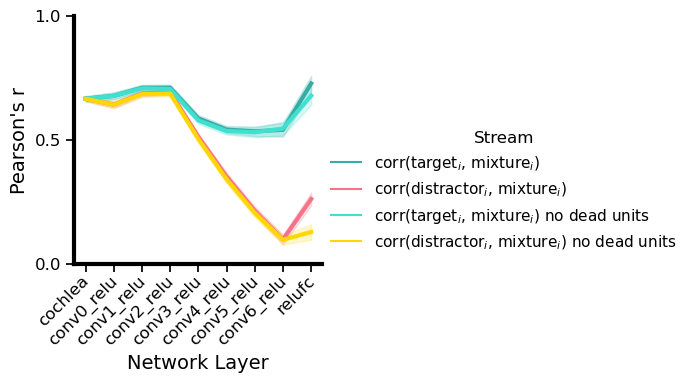

In [49]:
### Plot cochleagram and activation layers only 
layers_to_plot = ['cochlea'] + [layer for layer in layer_order if 'relu' in layer]


## Plot summary_results df 
sns.set_context('notebook')
# order = np.sort(results.layer.unique())
# plt.rc('font', family='Helvetica')

hue_order = ['corr(target$_i$, mixture$_i$)', 'corr(distractor$_i$, mixture$_i$)',  'corr(target$_i$, mixture$_i$) no dead units', 'corr(distractor$_i$, mixture$_i$) no dead units'] 
# make palette for models in husl 
palette = sns.color_palette("husl", 2)
# make palette dict 
palette_dict = {'corr(target$_i$, mixture$_i$)': palette[1],
                'corr(distractor$_i$, mixture$_i$)': palette[0],
                'corr(target$_i$, mixture$_i$) no dead units': 'turquoise',
                'corr(distractor$_i$, mixture$_i$) no dead units': 'gold',
                }

# add line style dict 
line_style_dict = {'corr(target$_i$, mixture$_i$)': '-',
                   'corr(distractor$_i$, mixture$_i$)': '-'}  

p = sns.relplot(kind='line', 
                data=to_plot[to_plot.layer.isin(layers_to_plot)], 
                # order=layer_order,
                x='layer',
                y="Pearson's r", #order=order,
                # col = 'distractor_condition', 
                hue = 'Stream',
                hue_order = hue_order,
                palette=palette_dict, 
                height=4, #aspect=2, 
                sort=False,
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)

            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=14
tick_fontsize = 12

p.set_axis_labels("Network Layer", "Pearson's r", size=fontsize)
p.set_titles("{col_name} distractor", size=fontsize, y=1.05)
# p.axes[0,0].xaxis.labelpad = -0.25
# set y limit to 0,1
p.set(ylim=(0,1))
# move x axis label up 

# p.set_
p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
# yticks = np.linspace(0,1,3).round(1)
ratio = 1.0

# increase axis thickness and set to square aspect

line_thickness = 3

for ax in p.axes.flat:
    xleft, xright = ax.get_xlim()
    ybottom, ytop = ax.get_ylim()
    ax.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)
    ax.set_yticks(ticks=yticks) # set new labels
    ax.set_yticklabels(labels= yticks, fontsize=tick_fontsize)
    for line in ax.get_lines():
        line.set_linewidth(line_thickness)
        line.set_linestyle('-')
        line.set_alpha(1)
        # remove marker 

    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(line_thickness)
        ax.spines[axis].set_color('k')

# replace legend with text of stream names 
# p._legend.remove()
# plt.suptitle("Stage of selection by distractor type", y=1.1, fontsize=fontsize+2)
# # add text 
# p.fig.text(0.305, 0.9, 'corr(target$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(target$_i$, mixture$_i$)'], ha='left');
# p.fig.text(0.305, 0.825, 'corr(distractor$_i$, mixture$_i$)', fontsize=tick_fontsize, color=palette_dict['corr(distractor$_i$, mixture$_i$)'], ha='left');

# plt.savefig(outfig_dest/'stage_of_selection_for_poster.pdf', transparent=True, bbox_inches='tight')



In [38]:
act_results

,fg_corrs_filt_du,bg_corrs_filt_du,fg_corrs_full,bg_corrs_full,layer,distractor_condition,model_name
0,0.686145,0.714581,0.688546,0.716776,conv1_relu,diff_sex_talker,Feature-gain v10
1,0.778940,0.631483,0.780571,0.634239,conv1_relu,diff_sex_talker,Feature-gain v10
2,0.723678,0.624687,0.725701,0.627489,conv1_relu,diff_sex_talker,Feature-gain v10
3,0.736681,0.656647,0.738703,0.659203,conv1_relu,diff_sex_talker,Feature-gain v10
4,0.648615,0.702501,0.651535,0.704785,conv1_relu,diff_sex_talker,Feature-gain v10
...,...,...,...,...,...,...,...
895,0.479374,0.005779,0.468907,0.006407,conv6_relu,diff_sex_talker,Feature-gain v10
896,0.586652,0.143595,0.581234,0.151889,conv6_relu,diff_sex_talker,Feature-gain v10
897,0.519234,0.080917,0.514782,0.080539,conv6_relu,diff_sex_talker,Feature-gain v10
898,0.616797,0.036538,0.608775,0.042773,conv6_relu,diff_sex_talker,Feature-gain v10


Text(0.5, 1.1, 'Stage of selection by distractor type')

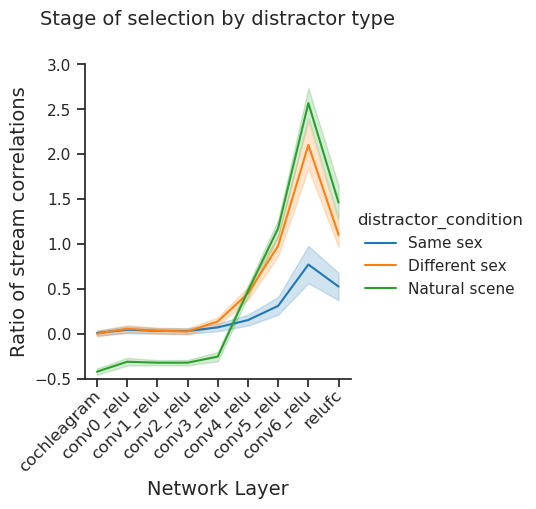

In [13]:
### Plot cochleagram and activation layers only 
layers_to_plot = ['cochleagram'] + [layer for layer in layer_order if 'relu' in layer]

to_plot = act_results.set_index('layer')
to_plot = to_plot.loc[layer_order].reset_index()

to_plot['distractor_condition'].replace('same_sex_talker','Same sex',inplace=True)
to_plot['distractor_condition'].replace('diff_sex_talker','Different sex',inplace=True)
to_plot['distractor_condition'].replace('natural_scene','Natural scene',inplace=True)


## Plot summary_results df 
sns.set_context('notebook')
# order = np.sort(results.layer.unique())
# plt.rc('font', family='Helvetica')

p = sns.relplot(kind='line', 
                data=to_plot[to_plot.layer.isin(layers_to_plot)], 
                # order=layer_order,
                x='layer',
                y="log_corr_ratio", #order=order,
                hue = 'distractor_condition', 
                height=4, #aspect=2, 
                sort=False,
            #   err_style='bars', err_kws={'elinewidth': 1},
                errorbar=('se', 2), seed=1)

            #   errorbar=('ci'), n_boot=10_000, seed=1)

fontsize=14
tick_fontsize = 12

p.set_axis_labels("Network Layer", "Ratio of stream correlations", size=fontsize)

# set y limit to 0,1
p.set(ylim=(-0.5, 3))
# move x axis label up 

# p.set_
p.set_xticklabels(rotation=45, size=tick_fontsize,  ha='right', va='center_baseline',  rotation_mode='anchor')
    
# set first row x and y limits to 0 1
# yticks = np.linspace(-2,2,5).round(1)
ratio = 1.0

# increase axis thickness and set to square aspect

line_thickness = 1.5
plt.title("Stage of selection by distractor type", y=1.1, fontsize=fontsize)
